# Notebook 3: Phase 2 - Regional Adaptation

**Sequential Transfer Learning for Medicinal Plant Identification**

---

## Purpose

Continue training the Phase 1 model on Dataset 2 (Bangladesh medicinal plants).

**Dataset 2 Info:**
- 6 species: Centella Asiatica, Coccinia Grandis, Eclipta Prostrata, Mikania Micrantha, Murraya Koenigii, Stephania Japonica
- Source: Guadanga village, Phulpur, Mymensingh, Bangladesh

```
Phase 1: General Features (Dataset 1)    DONE
    | (knowledge transfers)
Phase 2: Regional Context (Dataset 2) <-- WE ARE HERE
    |
Phase 3: Specialization (Datasets 4 & 5)
```

---

**Key Concept:** We LOAD the Phase 1 model from Google Drive and continue training!

## 1. Mount Google Drive & Setup

In [1]:
# Mount Google Drive
from google.colab import drive

print(">>> Mounting Google Drive...")
drive.mount('/content/drive', force_remount=True)
print(">>>>> Google Drive mounted!")

>>> Mounting Google Drive...
Mounted at /content/drive
>>>>> Google Drive mounted!


In [2]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print(f"TensorFlow version: {tf.__version__}")

# check for GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f">>> GPU detected: {gpus[0].name}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("WARNING: No GPU detected")

TensorFlow version: 2.19.0
>>> GPU detected: /physical_device:GPU:0


In [3]:
# Configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 0.0001  # lower LR since we're fine-tuning
VALIDATION_SPLIT = 0.2
SEED = 42

# Google Drive paths
DRIVE_BASE = "/content/drive/MyDrive"
PROJECT_DIR = os.path.join(DRIVE_BASE, "MedicinalPlant_Dissertation")
DATA_DIR = os.path.join(PROJECT_DIR, "data")
MODEL_DIR = os.path.join(PROJECT_DIR, "models")

# Phase 1 model (from Google Drive)
PHASE1_MODEL_PATH = os.path.join(MODEL_DIR, "phase1_baseline.keras")

print(">>> Configuration loaded")
print(f"   Learning rate: {LEARNING_RATE} (lower for fine-tuning)")

>>> Configuration loaded
   Learning rate: 0.0001 (lower for fine-tuning)


## 2. Load Phase 1 Model from Google Drive

This is the key step - we load the model trained in Phase 1!

In [4]:
# Check if Phase 1 model exists
if not os.path.exists(PHASE1_MODEL_PATH):
    raise FileNotFoundError(
        f"Phase 1 model not found!\n"
        f"Expected: {PHASE1_MODEL_PATH}\n\n"
        "Please run 02_phase1_baseline.ipynb first!"
    )

print(f">>> Loading Phase 1 model from Google Drive...")
print(f"   {PHASE1_MODEL_PATH}")

phase1_model = keras.models.load_model(PHASE1_MODEL_PATH)

print("\n>>>>> Phase 1 model loaded!")
print(f"   Original classes: {phase1_model.output_shape[-1]}")
print("   Species: Arjun, Curry, Marsh Pennywort, Mint, Neem, Rubble")

>>> Loading Phase 1 model from Google Drive...
   /content/drive/MyDrive/MedicinalPlant_Dissertation/models/phase1_baseline.keras

>>>>> Phase 1 model loaded!
   Original classes: 6
   Species: Arjun, Curry, Marsh Pennywort, Mint, Neem, Rubble


## 3. Find and Load Dataset 2

In [5]:
# Extract Dataset 2 if needed
import zipfile

zip_path = os.path.join(DATA_DIR, "dataset2.zip")
extract_dir = os.path.join(DATA_DIR, "dataset2")

if os.path.exists(extract_dir) and len(os.listdir(extract_dir)) > 0:
    print(">>>>> Dataset 2 already extracted in Google Drive - SKIPPING")
else:
    print(">>> Extracting dataset2.zip...")
    os.makedirs(extract_dir, exist_ok=True)

    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_dir)

    # Handle nested zips
    for root, dirs, files in os.walk(extract_dir):
        for file in files:
            if file.endswith('.zip'):
                nested = os.path.join(root, file)
                print(f"   -> Extracting {file}")
                with zipfile.ZipFile(nested, 'r') as z:
                    z.extractall(root)
                os.remove(nested)

    print(">>>>> Dataset 2 extracted!")

>>>>> Dataset 2 already extracted in Google Drive - SKIPPING


In [6]:
def find_image_directory(base_dir):
    """Find the directory containing class folders with images."""
    if not os.path.exists(base_dir):
        return None

    for root, dirs, files in os.walk(base_dir):
        dirs[:] = [d for d in dirs if not d.startswith('.')]

        if not dirs:
            continue

        sample_dir = os.path.join(root, dirs[0])
        if os.path.isdir(sample_dir):
            sample_files = os.listdir(sample_dir)
            has_images = any(f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
                           for f in sample_files)
            if has_images:
                return root
    return None

# Find Dataset 2
print(">>> Finding Dataset 2...")

# try config file first
config_path = os.path.join(PROJECT_DIR, "dataset_config.json")
DATASET2_PATH = None

if os.path.exists(config_path):
    with open(config_path, 'r') as f:
        config = json.load(f)
    DATASET2_PATH = config.get("dataset_paths", {}).get("dataset2")
    if DATASET2_PATH:
        print(f"   Found via config file")

# fallback: auto-find
if not DATASET2_PATH or not os.path.exists(DATASET2_PATH):
    print("   Searching data directory...")
    dataset2_base = os.path.join(DATA_DIR, "dataset2")
    DATASET2_PATH = find_image_directory(dataset2_base)

# Check result
if DATASET2_PATH and os.path.exists(DATASET2_PATH):
    print(f"\n>>>>> Dataset 2 found!")
    print(f"   Path: {DATASET2_PATH}")
else:
    raise FileNotFoundError(
        "Dataset 2 not found!\n\n"
        "Please run 01_data_exploration.ipynb first."
    )

>>> Finding Dataset 2...
   Searching data directory...

>>>>> Dataset 2 found!
   Path: /content/drive/MyDrive/MedicinalPlant_Dissertation/data/dataset2/A dataset of medicinal plant leaves from Banglades/Leaf_Dataset_Augmented


In [7]:
# Load Dataset 2
print(">>> Loading Dataset 2 (Bangladesh - 6 species)...")
print("   Species: Centella, Coccinia, Eclipta, Mikania, Murraya, Stephania\n")

train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET2_PATH,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET2_PATH,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

class_names = train_dataset.class_names
NUM_CLASSES = len(class_names)

print(f">>>>> Dataset 2 loaded!")
print(f"   Classes: {NUM_CLASSES}")
print(f"   Class names: {class_names}")

>>> Loading Dataset 2 (Bangladesh - 6 species)...
   Species: Centella, Coccinia, Eclipta, Mikania, Murraya, Stephania

Found 2188 files belonging to 6 classes.
Using 1751 files for training.
Found 2188 files belonging to 6 classes.
Using 437 files for validation.
>>>>> Dataset 2 loaded!
   Classes: 6
   Class names: ['Centella Asiatica', 'Coccinia Grandis', 'Eclipta Prostrata', 'Mikania Micrantha', 'Murraya koenigii', 'Stephania Japonica']


In [8]:
# Preprocessing
normalization = layers.Rescaling(1./255)  # scale to [0,1]
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.map(lambda x, y: (normalization(x), y))
val_dataset = val_dataset.map(lambda x, y: (normalization(x), y))

train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print(">>> Datasets normalized")

>>> Datasets normalized


## 4. Adapt Model for New Classes

We keep the ResNet50 feature extractor and replace the classification head.

In [9]:
# Extract ResNet50 base from Phase 1 model
print(">>> Adapting model for Dataset 2...")
print("\n   Phase 1 -> Phase 2 Transfer:")
print("   - Keeping: ResNet50 features (6 species knowledge)")
print("   - Replacing: Classification head (new 6 species)")

# find the resnet50 layer by name (not hardcoded index)
resnet_base = None
for layer in phase1_model.layers:
    if 'resnet' in layer.name.lower():
        resnet_base = layer
        break

# fallback: look for any layer with lots of sub-layers (i.e. a big model block)
if resnet_base is None:
    for layer in phase1_model.layers:
        if hasattr(layer, 'layers') and len(layer.layers) > 10:
            resnet_base = layer
            break

if resnet_base is None:
    raise RuntimeError("Could not find ResNet50 base in Phase 1 model!")

resnet_base.trainable = False  # keep features frozen initially

print(f"\n   Extracted: {resnet_base.name}")
print(f"   Parameters: {resnet_base.count_params():,}")
print(f"   This base carries knowledge from: ImageNet -> Dataset 1")

>>> Adapting model for Dataset 2...

   Phase 1 -> Phase 2 Transfer:
   - Keeping: ResNet50 features (6 species knowledge)
   - Replacing: Classification head (new 6 species)

   Extracted: resnet50
   Parameters: 23,587,712
   This base carries knowledge from: ImageNet -> Dataset 1


In [10]:
# Build new model for Dataset 2 (uses Phase 1 base - true sequential transfer)
# The resnet_base was extracted from Phase 1 in the cell above.
# Transfer chain: ImageNet -> Phase 1 -> Phase 2
print(">>> Building Phase 2 model with Phase 1 ResNet50 base...")
print("   Transfer chain: ImageNet -> Phase 1 -> Phase 2")
print(f"   Using base: {resnet_base.name} (from Phase 1, NOT fresh ImageNet)")

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="augmentation")

model = keras.Sequential([
    keras.Input(shape=(224, 224, 3)),
    data_augmentation,
    resnet_base,  # Phase 1 trained base - true sequential transfer
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')  # new head for dataset 2
], name="phase2_regional")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"\n>>>>> Model built for {NUM_CLASSES} Dataset 2 classes")
print("   ResNet50 base carries Phase 1 learned features!")
model.summary()

>>> Building Phase 2 model with Phase 1 ResNet50 base...
   Transfer chain: ImageNet -> Phase 1 -> Phase 2
   Using base: resnet50 (from Phase 1, NOT fresh ImageNet)

>>>>> Model built for 6 Dataset 2 classes
   ResNet50 base carries Phase 1 learned features!


Model: "phase2_regional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,650,118 (94.03 MB)

 Trainable params: 1,057,286 (4.03 MB)

 Non-trainable params: 23,592,832 (90.00 MB)

## 5. Train Phase 2

In [11]:
# Callbacks - SAVED TO GOOGLE DRIVE
import os
MODEL_PATH = os.path.join(MODEL_DIR, "phase2_regional.keras")

callbacks = [
    ModelCheckpoint(MODEL_PATH, monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7, verbose=1)
]

print(f">>> Model will be saved to Google Drive:")
print(f"   {MODEL_PATH}")

>>> Model will be saved to Google Drive:
   /content/drive/MyDrive/MedicinalPlant_Dissertation/models/phase2_regional.keras


In [12]:
# Train
print("\n" + "="*50)
print(">>>>> STARTING PHASE 2 TRAINING")
print("="*50)
print(f"Dataset: Dataset 2 - Bangladesh ({NUM_CLASSES} species)")
print(f"Base model: ResNet50 (with Phase 1 knowledge)")
print("="*50 + "\n")

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print("\n" + "="*50)
print(">>>>> PHASE 2 TRAINING COMPLETE!")
print("="*50)


>>>>> STARTING PHASE 2 TRAINING
Dataset: Dataset 2 - Bangladesh (6 species)
Base model: ResNet50 (with Phase 1 knowledge)

Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.2330 - loss: 2.2492
Epoch 1: val_accuracy improved from -inf to 0.16705, saving model to /content/drive/MyDrive/MedicinalPlant_Dissertation/models/phase2_regional.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 343s 6s/step - accuracy: 0.2344 - loss: 2.2452 - val_accuracy: 0.1670 - val_loss: 1.7482 - learning_rate: 1.0000e-04
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.4189 - loss: 1.6140
Epoch 2: val_accuracy did not improve from 0.16705
55/55 ━━━━━━━━━━━━━━━━━━━━ 9s 160ms/step - accuracy: 0.4195 - loss: 1.6125 - val_accuracy: 0.1670 - val_loss: 1.7097 - learning_rate: 1.0000e-04
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.5081 - loss: 1.4069
Epoch 3: val_accuracy improved from 0.16705 to 0.17849, saving model to /content/drive/MyDrive/MedicinalPlant_Dissertation/models/ph

## 6. Results

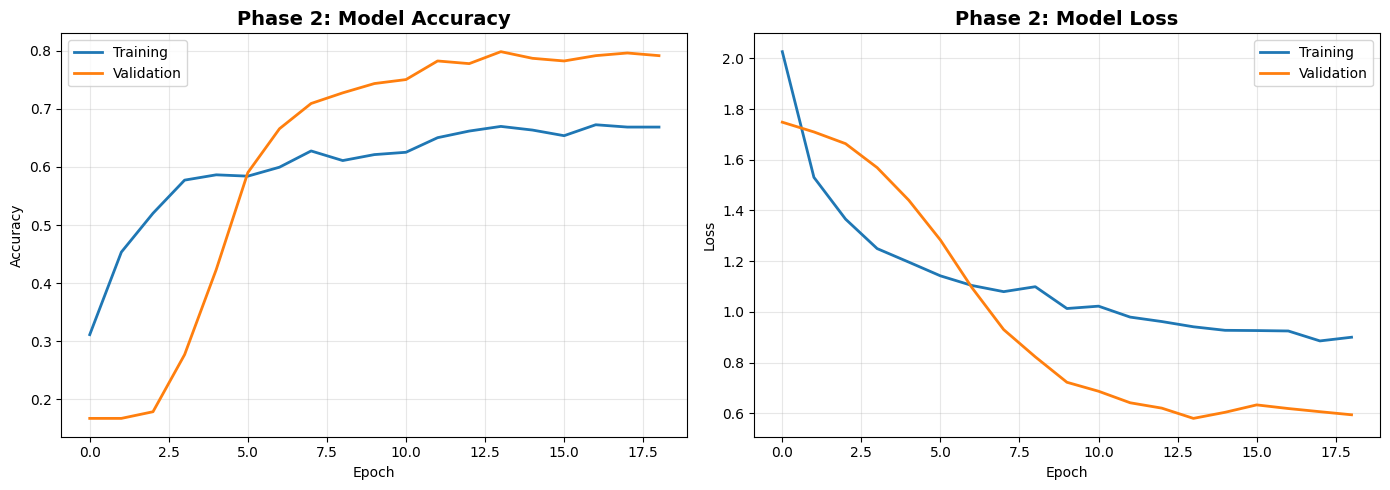

In [13]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Training', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Phase 2: Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Training', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Phase 2: Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'phase2_training_curves.png'), dpi=150)
plt.show()

In [14]:
# Final evaluation
val_loss, val_accuracy = model.evaluate(val_dataset, verbose=0)

print(">>> Phase 2 Results")
print("=" * 40)
print(f"   Validation Accuracy: {val_accuracy*100:.1f}%")
print(f"   Validation Loss: {val_loss:.4f}")
print("=" * 40)

>>> Phase 2 Results
   Validation Accuracy: 79.9%
   Validation Loss: 0.5795


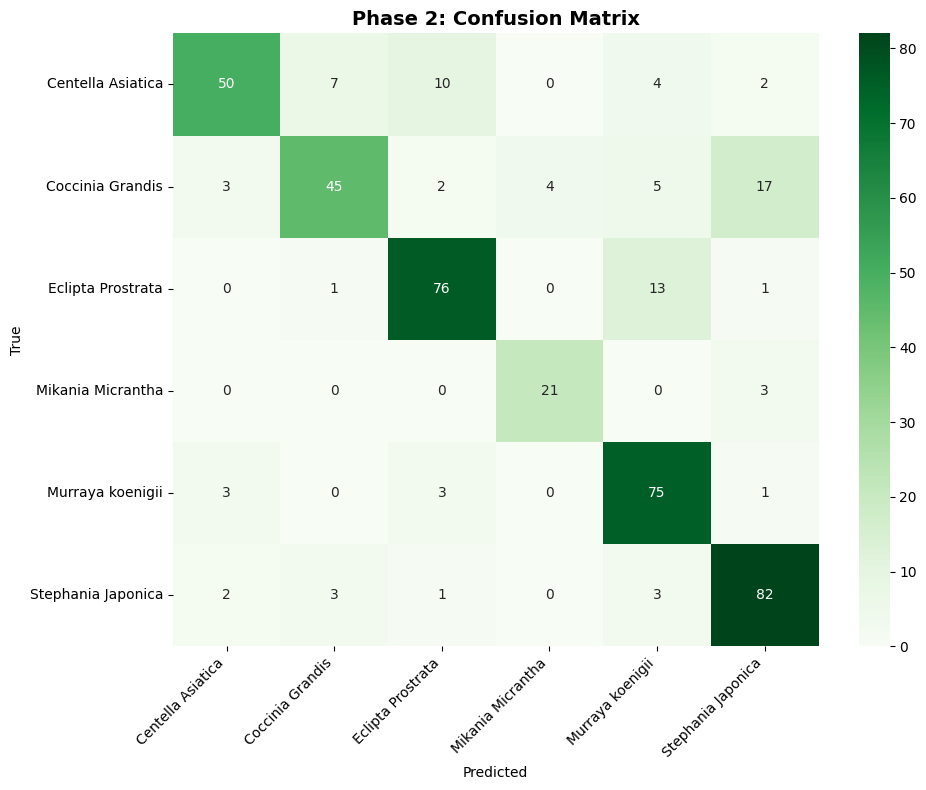

In [15]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_true, y_pred = [], []
for images, labels in val_dataset:
    predictions = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Phase 2: Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'phase2_confusion_matrix.png'), dpi=150)
plt.show()

In [16]:
# Classification report
print(">>> Classification Report")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=class_names))

>>> Classification Report
                    precision    recall  f1-score   support

 Centella Asiatica       0.86      0.68      0.76        73
  Coccinia Grandis       0.80      0.59      0.68        76
 Eclipta Prostrata       0.83      0.84      0.83        91
 Mikania Micrantha       0.84      0.88      0.86        24
  Murraya koenigii       0.75      0.91      0.82        82
Stephania Japonica       0.77      0.90      0.83        91

          accuracy                           0.80       437
         macro avg       0.81      0.80      0.80       437
      weighted avg       0.80      0.80      0.79       437



In [17]:
# Save model and metadata to Google Drive
model.save(MODEL_PATH)
print(f">>>>> Model saved: {MODEL_PATH}")

with open(os.path.join(MODEL_DIR, "phase2_class_names.json"), 'w') as f:
    json.dump(class_names, f)

with open(os.path.join(MODEL_DIR, "phase2_history.json"), 'w') as f:
    history_dict = {k: [float(v) for v in vals] for k, vals in history.history.items()}
    json.dump(history_dict, f)

print(">>>>> All Phase 2 artifacts saved to Google Drive")

>>>>> Model saved: /content/drive/MyDrive/MedicinalPlant_Dissertation/models/phase2_regional.keras
>>>>> All Phase 2 artifacts saved to Google Drive


## 7. Summary

### Sequential Transfer Learning Demonstrated!

| Phase | Dataset | Species | Knowledge Source |
|-------|---------|---------|------------------|
| 1 | Dataset 1 | 6 (Arjun, Curry...) | ImageNet |
| 2 | Dataset 2 | 6 (Centella, Coccinia...) | Phase 1 + ImageNet |

### Files Saved to Google Drive:
- `models/phase2_regional.keras`
- `phase2_training_curves.png`
- `phase2_confusion_matrix.png`

In [18]:
print("\n" + "="*60)
print(">>>>> PHASE 2 COMPLETE!")
print("="*60)
print(f"\n>>> Results:")
print(f"   Accuracy: {max(history.history['val_accuracy'])*100:.1f}%")
print(f"   Species: {', '.join(class_names)}")
print(f"\nModel saved to Google Drive:")
print(f"   {MODEL_PATH}")
print(f"\nSequential transfer learning demonstrated!")
print("   Phase 1 features helped train Phase 2.")


>>>>> PHASE 2 COMPLETE!

>>> Results:
   Accuracy: 79.9%
   Species: Centella Asiatica, Coccinia Grandis, Eclipta Prostrata, Mikania Micrantha, Murraya koenigii, Stephania Japonica

Model saved to Google Drive:
   /content/drive/MyDrive/MedicinalPlant_Dissertation/models/phase2_regional.keras

Sequential transfer learning demonstrated!
   Phase 1 features helped train Phase 2.
